In [1]:
# how to uncover truths that don't matter - third section

In [2]:
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd
from sklearn.linear_model import LinearRegression

In [3]:
# loading dataframe with not cancelled flights
fdf = pd.read_csv("data/coriolis_flights_3m.csv", sep=";").astype(
    {
    "FL_DATE": "datetime64[ns]", 
    "AIRLINE": "category", 
    "AIRLINE_DOT": "category", 
    "AIRLINE_CODE": "category", 
    "ORIGIN": "category", 
    "ORIGIN_CITY": "category", 
    "DEST": "category",
    "DEST_CITY": "category", 
    "CANCELLED": "bool",
    "CANCELLATION_CODE": "category", 
    "DIVERTED": "bool",
    }
)

In [4]:
fdf.dtypes

FL_DATE                    datetime64[ns]
AIRLINE                          category
AIRLINE_DOT                      category
AIRLINE_CODE                     category
DOT_CODE                            int64
FL_NUMBER                           int64
ORIGIN                           category
ORIGIN_CITY                      category
DEST                             category
DEST_CITY                        category
CRS_DEP_TIME                        int64
DEP_TIME                          float64
DEP_DELAY                         float64
TAXI_OUT                          float64
WHEELS_OFF                        float64
WHEELS_ON                         float64
TAXI_IN                           float64
CRS_ARR_TIME                        int64
ARR_TIME                          float64
ARR_DELAY                         float64
CANCELLED                            bool
CANCELLATION_CODE                category
DIVERTED                             bool
CRS_ELAPSED_TIME                  

In [5]:
# cleaning data for machiene learning (linear regression and fitting polynomials)

In [6]:
print("number of rows before further cleaning: ", rows_before_cleaning := len(fdf))

number of rows before further cleaning:  3000000


In [7]:
fdf.dropna(subset=["DEP_DELAY", "ARR_DELAY"], inplace=True)

In [8]:
print("number of rows after cleaning: ", len(fdf))
print("number of rows lost due cleaning: ", rows_before_cleaning - len(fdf))

number of rows after cleaning:  2913802
number of rows lost due cleaning:  86198


In [9]:
# linear regression in numpy is identical to fitting a polynomial of order one.

In [10]:
# linear regression using numpy
m, b = np.polyfit(fdf["DEP_DELAY"], fdf["ARR_DELAY"],1 )

In [11]:
# printing slope and intercept calculated with numpy
print("Slope by numpy (m): ", m)
print("Intercept by numpy (b): ", b)

Slope by numpy (m):  1.0066024236688085
Intercept by numpy (b):  -5.855591520042682


In [12]:
# and calculate R²
poly = np.poly1d([m, b])
y_predictions = poly(fdf["DEP_DELAY"])

ss_res = np.sum((fdf["ARR_DELAY"] - y_predictions) ** 2) # residual sum of squares 
ss_tot = np.sum((fdf["ARR_DELAY"] - np.mean(fdf["ARR_DELAY"])) ** 2) # total sum of squares

poly_r_squared = 1 - (ss_res / ss_tot)
                
print(f"Coefficients for polynomial: m = {m}; b = {b}")
print("R² of the polynomial: ", poly_r_squared)

Coefficients for polynomial: m = 1.0066024236688085; b = -5.855591520042682
R² of the polynomial:  0.9308487338797917


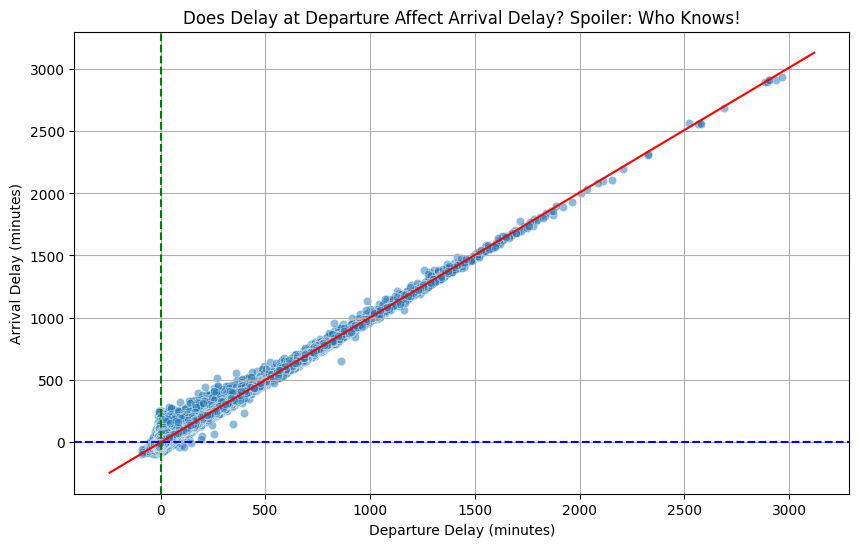

In [13]:
# plotting linear regression of our first question
plt.figure(figsize=(10, 6))
sns.scatterplot(x="DEP_DELAY", y="ARR_DELAY", data=fdf, alpha=0.5)

plt.title("Does Delay at Departure Affect Arrival Delay? Spoiler: Who Knows!")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for on-time arrivals
plt.axvline(0, color="green", linestyle="--")  # Reference line for on-time departures

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = b + m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.show()

Slope by scikit-learn (m):  1.0066024236688076
Intercept by scikit-learn (b):  -5.855591520042689
R² by scikit-learn:  0.9308487338797917


/home/jnja/cs/.venvs/ds/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


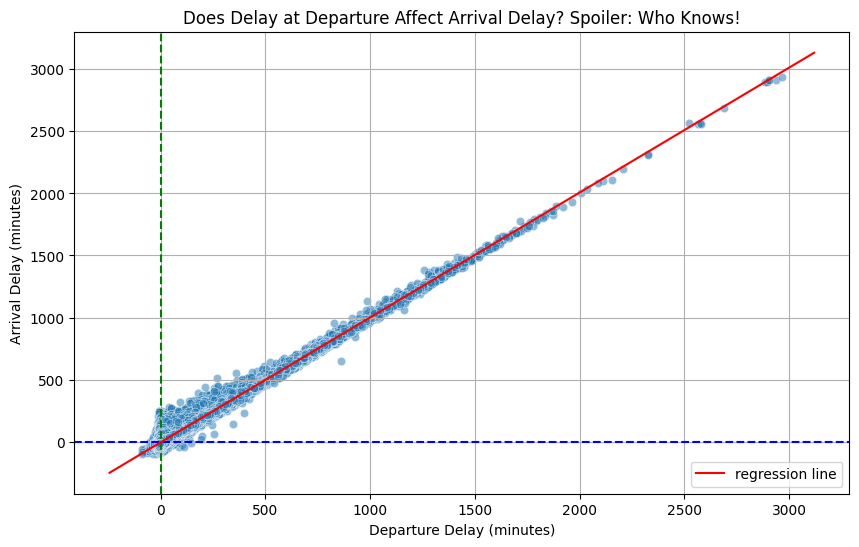

In [14]:
# linear regression using scikit-learn
X = fdf["DEP_DELAY"].values.reshape(-1, 1)
Y = fdf["ARR_DELAY"].values

model = LinearRegression()
model.fit(X, Y)

m = model.coef_[0]
b = model.intercept_
r_squared = model.score(X, Y)

print("Slope by scikit-learn (m): ", m)
print("Intercept by scikit-learn (b): ", b)
print("R² by scikit-learn: ", r_squared)

# checking if model checks out visually 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="DEP_DELAY", y="ARR_DELAY", data=fdf, alpha=0.5)

plt.title("Does Delay at Departure Affect Arrival Delay? Spoiler: Who Knows!")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.axhline(0, color="blue", linestyle="--")  # Reference line for x-axis
plt.axvline(0, color="green", linestyle="--")  # Reference line for y-axis

# adding in line 
x_vals = np.array(plt.gca().get_xlim())
y_vals = b + m * x_vals

plt.plot(x_vals, y_vals, color="red", label="regression line")

plt.grid(True)
plt.legend()
plt.show()